# 01. EDA исходных RRUFF и opXRD

Графики сохраняются в `reports/figures/01_real_data_eda/`, таблицы — в
`reports/tables/01_real_data_eda/`.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("неверный путь.")

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from project_paths import *
ensure_project_directories()

print("Project root:", PROJECT_ROOT)

Project root: D:\Users\user\Desktop\DS_XRD_project


In [ ]:
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")

FIG_DIR = FIGURES_DIR / "01_real_data_eda"
TAB_DIR = TABLES_DIR / "01_real_data_eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

## RRUFF: чтение и общая структура

In [ ]:
with RAW_SOURCES["rruff_json"].open("r", encoding="utf-8") as stream:
    rruff_raw = json.load(stream)

print(f"RRUFF records: {len(rruff_raw):,}")

display(pd.Series(Counter(k for row in rruff_raw for k in row), name="rows_with_field")
        .sort_values(ascending=False).to_frame())

RRUFF records: 1,362


,rows_with_field
##NAMES,1362
##RRUFFID,1362
##LOCALITY,1362
##OWNER,1362
##SOURCE,1362
##STATUS,1362
x,1362
##END,1362
##URL,1362
elements,1362


## RRUFF: спектры, решётки и химический состав

In [ ]:
valid_elements = re.compile(r"[A-Z][a-z]?")
rruff_rows = []

for row in rruff_raw:
    
    x = np.asarray(row.get("x", []), dtype=float)
    y = np.asarray(row.get("y", []), dtype=float)

    cell = row.get("##CELL PARAMETERS") or ""
    system_match = re.search(r"crystal system:\s*([A-Za-z]+)", cell, re.I)

    rruff_rows.append({
        "rruff_id": row.get("##RRUFFID"),
        "mineral": row.get("##NAMES"),
        "formula": row.get("formula"),
        "n_points": len(x),
        "x_min": float(x.min()) if len(x) else np.nan,
        "x_max": float(x.max()) if len(x) else np.nan,
        "step_median": float(np.median(np.diff(x))) if len(x) > 1 else np.nan,
        "intensity_max": float(y.max()) if len(y) else np.nan,
        "has_cell": bool(cell),
        "crystal_system": system_match.group(1).lower() if system_match else None,
        "n_elements": len(row.get("elements") or []),
    })
    
rruff_eda = pd.DataFrame(rruff_rows)
rruff_eda.to_parquet(TAB_DIR / "rruff_raw_eda.parquet", index=False)
display(rruff_eda.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rruff_id,1362,1359,R050630,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mineral,1362,806,Grossular,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
formula,1362,1084,Ca3Al2(SiO4)3,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_points,1362.0,NaN,NaN,NaN,8212.889134,1355.970396,851.0,8501.0,8501.0,8501.0,8504.0
x_min,1362.0,NaN,NaN,NaN,5.017527,0.441698,0.0,5.0,5.0,5.0,12.0142
x_max,1362.0,NaN,NaN,NaN,88.3513,8.198623,33.99,90.0,90.0,90.0,90.0
step_median,1362.0,NaN,NaN,NaN,0.010751,0.00442,0.0084,0.01,0.01,0.01,0.1
intensity_max,1362.0,NaN,NaN,NaN,1036.40169,1591.970391,21.979,260.216675,592.5667,1211.7735,29444.66
has_cell,1362,2,True,1298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crystal_system,1298,7,monoclinic,414,NaN,NaN,NaN,NaN,NaN,NaN,NaN


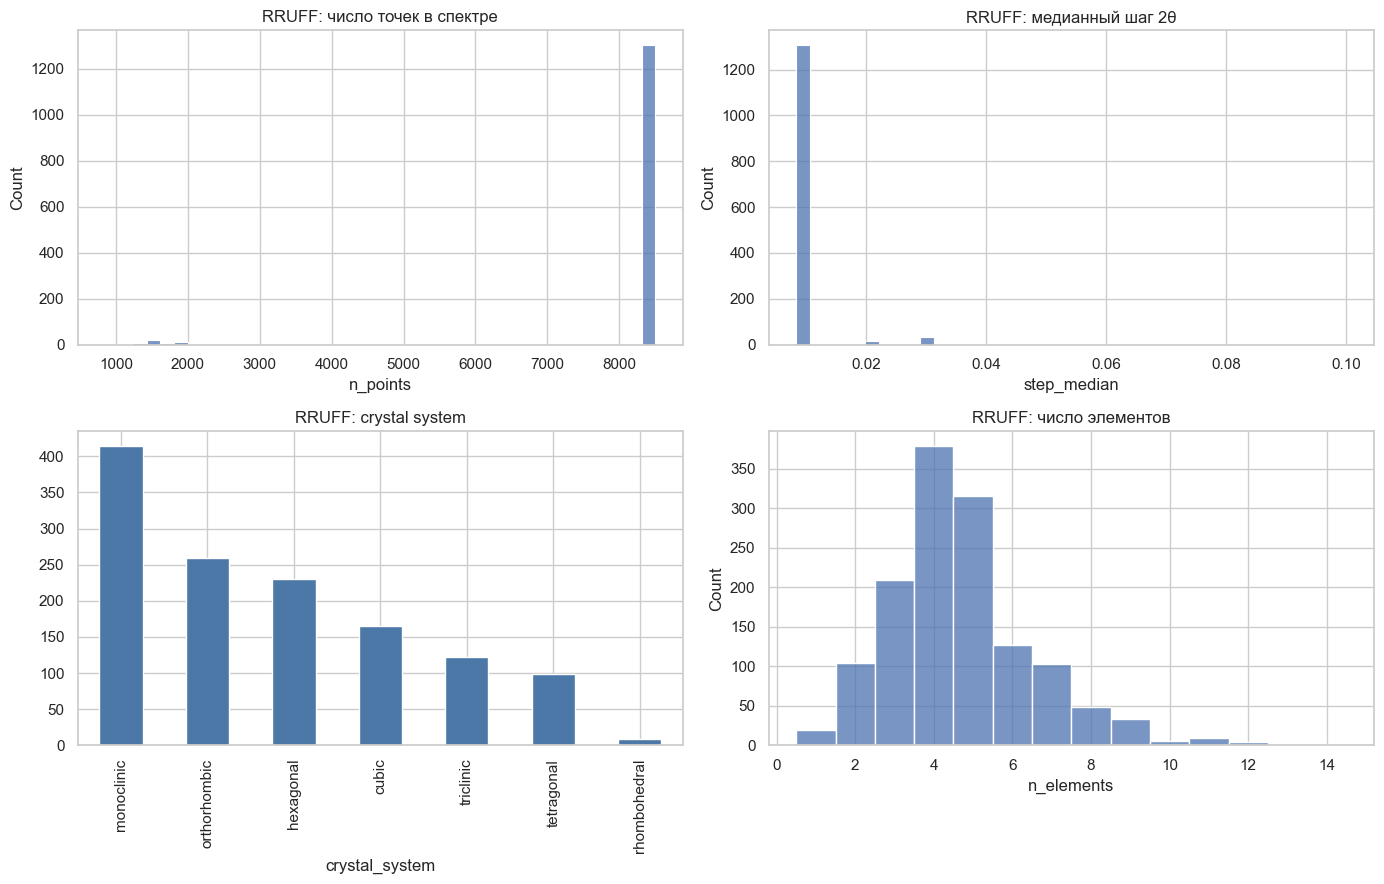

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(rruff_eda, x="n_points", bins=40, ax=axes[0, 0])
axes[0, 0].set_title("RRUFF: число точек в спектре")

sns.histplot(rruff_eda, x="step_median", bins=40, ax=axes[0, 1])
axes[0, 1].set_title("RRUFF: медианный шаг 2θ")

rruff_eda["crystal_system"].value_counts().plot.bar(ax=axes[1, 0], color="#4C78A8")
axes[1, 0].set_title("RRUFF: crystal system")

sns.histplot(rruff_eda, x="n_elements", discrete=True, ax=axes[1, 1])
axes[1, 1].set_title("RRUFF: число элементов")

plt.tight_layout()
plt.savefig(FIG_DIR / "rruff_overview.png", dpi=160, bbox_inches="tight")
plt.show()

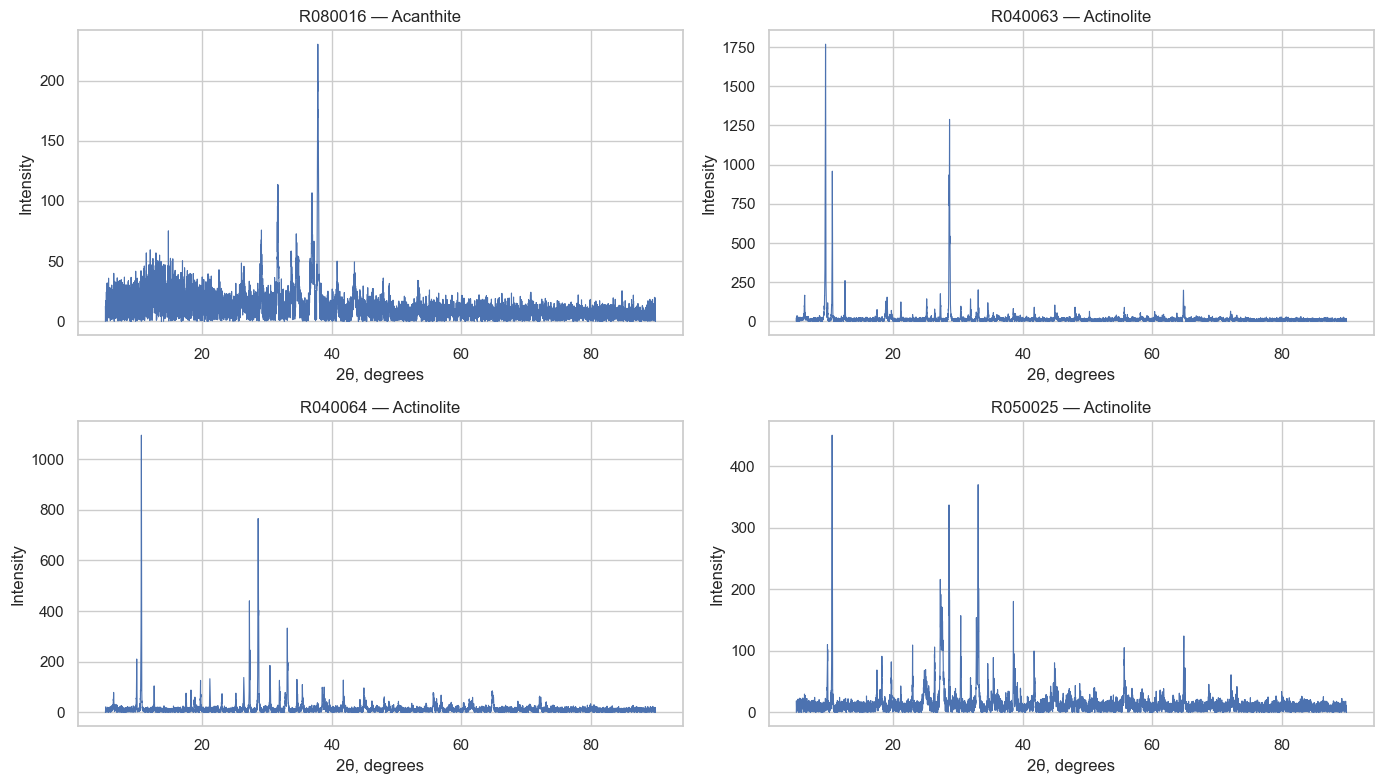

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, row in zip(axes.ravel(), rruff_raw[:4]):
    ax.plot(row["x"], row["y"], lw=0.8)
    ax.set_title(f'{row.get("##RRUFFID")} — {row.get("##NAMES")}')
    ax.set_xlabel("2θ, degrees")
    ax.set_ylabel("Intensity")
    
plt.tight_layout()
plt.savefig(FIG_DIR / "rruff_spectrum_examples.png", dpi=160, bbox_inches="tight")
plt.show()

## opXRD: аудит 92 тысяч JSON

In [ ]:
opxrd_files = list(RAW_SOURCES["opxrd_root"].rglob("pattern_*.json"))
print(f"opXRD JSON files: {len(opxrd_files):,}")

opxrd_rows = []
for path in tqdm(opxrd_files, desc="Reading opXRD metadata"):
    try:
        item = json.loads(path.read_text(encoding="utf-8"))

    except Exception:
        continue

    theta = item.get("two_theta_values") or []
    label_raw = item.get("label")
    label = {}

    if label_raw:
        try:
            label = json.loads(label_raw)

        except Exception:
            label = {}

    phases = label.get("phases") or []
    xray = {}

    try:
        xray = json.loads(label.get("xray_info", "{}"))

    except Exception:
        pass

    parsed_phases = []

    for phase in phases:
        try:
            parsed_phases.append(json.loads(phase) if isinstance(phase, str) else phase)

        except Exception:
            pass

    opxrd_rows.append({
        "file": str(path),
        "institution": path.relative_to(RAW_SOURCES["opxrd_root"]).parts[0],
        "n_points": len(theta),
        "x_min": min(theta) if theta else np.nan,
        "x_max": max(theta) if theta else np.nan,
        "has_label": bool(label_raw),
        "phase_count": len(phases),
        "primary_wavelength": xray.get("primary_wavelength"),
        "secondary_wavelength": xray.get("secondary_wavelength"),
        "has_lattice": any(bool(p.get("lattice")) for p in parsed_phases),
        "has_spacegroup": any(bool(p.get("spacegroup")) for p in parsed_phases),
        "has_composition": any(bool(p.get("chemical_composition")) for p in parsed_phases),
    })

opxrd_eda = pd.DataFrame(opxrd_rows)
opxrd_eda.to_parquet(TAB_DIR / "opxrd_raw_eda.parquet", index=False)

display(opxrd_eda.describe(include="all").T)

opXRD JSON files: 92,552


Reading opXRD metadata: 100%|██████████| 92552/92552 [12:03<00:00, 127.97it/s]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
file,92552,92552,D:\Users\user\Desktop\DS XRD\opxrd\USC\pattern...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
institution,92552,7,LBNL,70012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_points,92552.0,NaN,NaN,NaN,1682.548546,2126.960772,50.0,670.0,945.0,2600.0,58165.0
x_min,92552.0,NaN,NaN,NaN,7.313303,6.26066,0.0,5.192783,5.627508,5.664605,80.0
x_max,92552.0,NaN,NaN,NaN,69.879512,13.966065,0.8322,70.333724,71.005785,71.654613,180.0
has_label,92552,1,True,92552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phase_count,92552.0,NaN,NaN,NaN,0.035569,0.241749,0.0,0.0,0.0,0.0,4.0
primary_wavelength,91722,229,1.23984,68322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
secondary_wavelength,22658,18,1.54439,9871,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_lattice,92552,2,False,91175,NaN,NaN,NaN,NaN,NaN,NaN,NaN


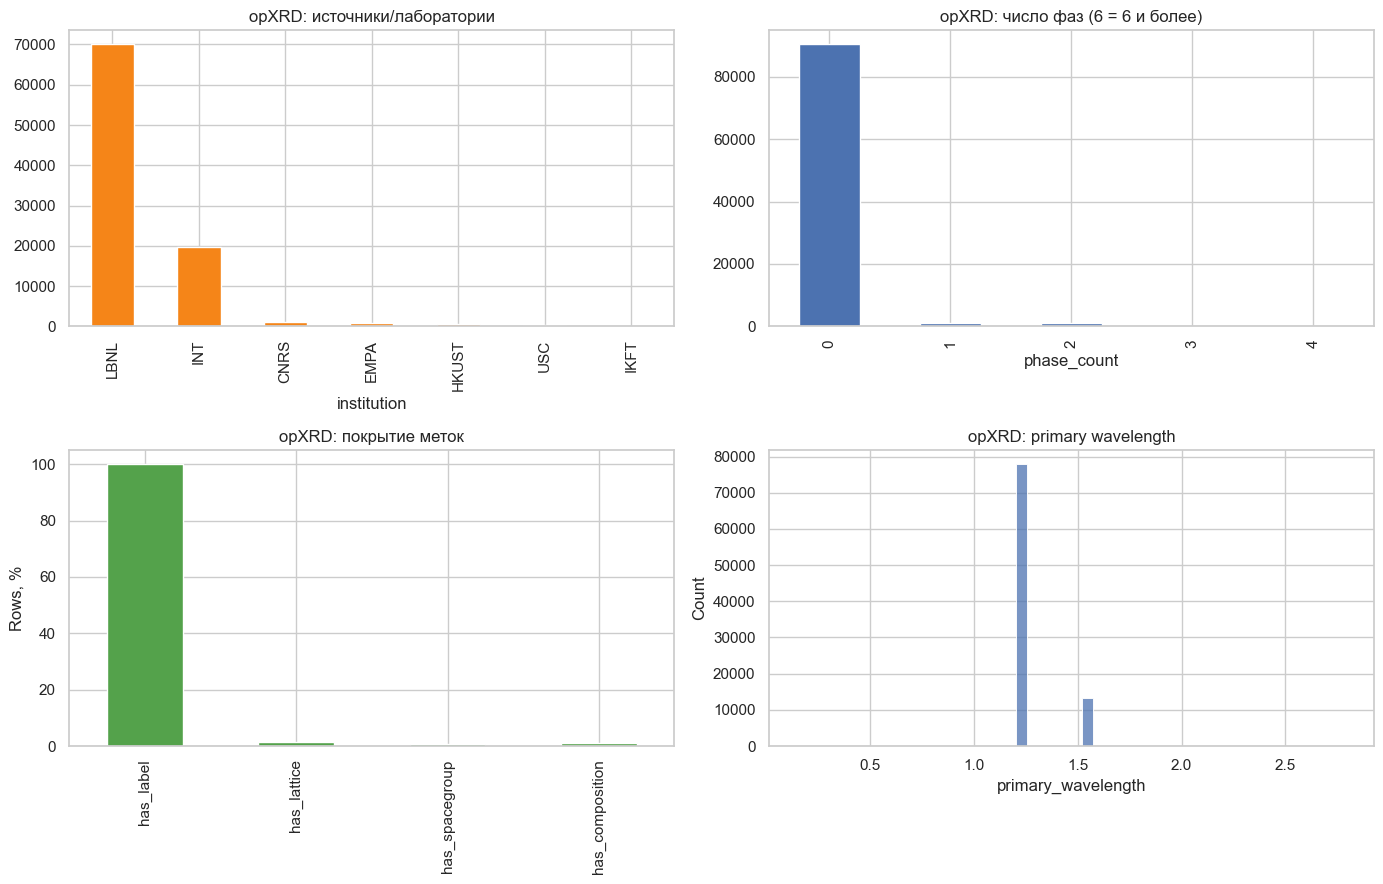

In [ ]:
coverage = opxrd_eda[["has_label", "has_lattice", "has_spacegroup", "has_composition"]].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

opxrd_eda["institution"].value_counts().plot.bar(ax=axes[0, 0], color="#F58518")
axes[0, 0].set_title("opXRD: источники/лаборатории")

opxrd_eda["phase_count"].clip(upper=6).value_counts().sort_index().plot.bar(ax=axes[0, 1])
axes[0, 1].set_title("opXRD: число фаз (6 = 6 и более)")

coverage.mul(100).plot.bar(ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_ylabel("Rows, %")

axes[1, 0].set_title("opXRD: покрытие меток")
wl = pd.to_numeric(opxrd_eda["primary_wavelength"], errors="coerce")

sns.histplot(wl.dropna(), bins=50, ax=axes[1, 1])
axes[1, 1].set_title("opXRD: primary wavelength")

plt.tight_layout()
plt.savefig(FIG_DIR / "opxrd_overview.png", dpi=160, bbox_inches="tight")
plt.show()

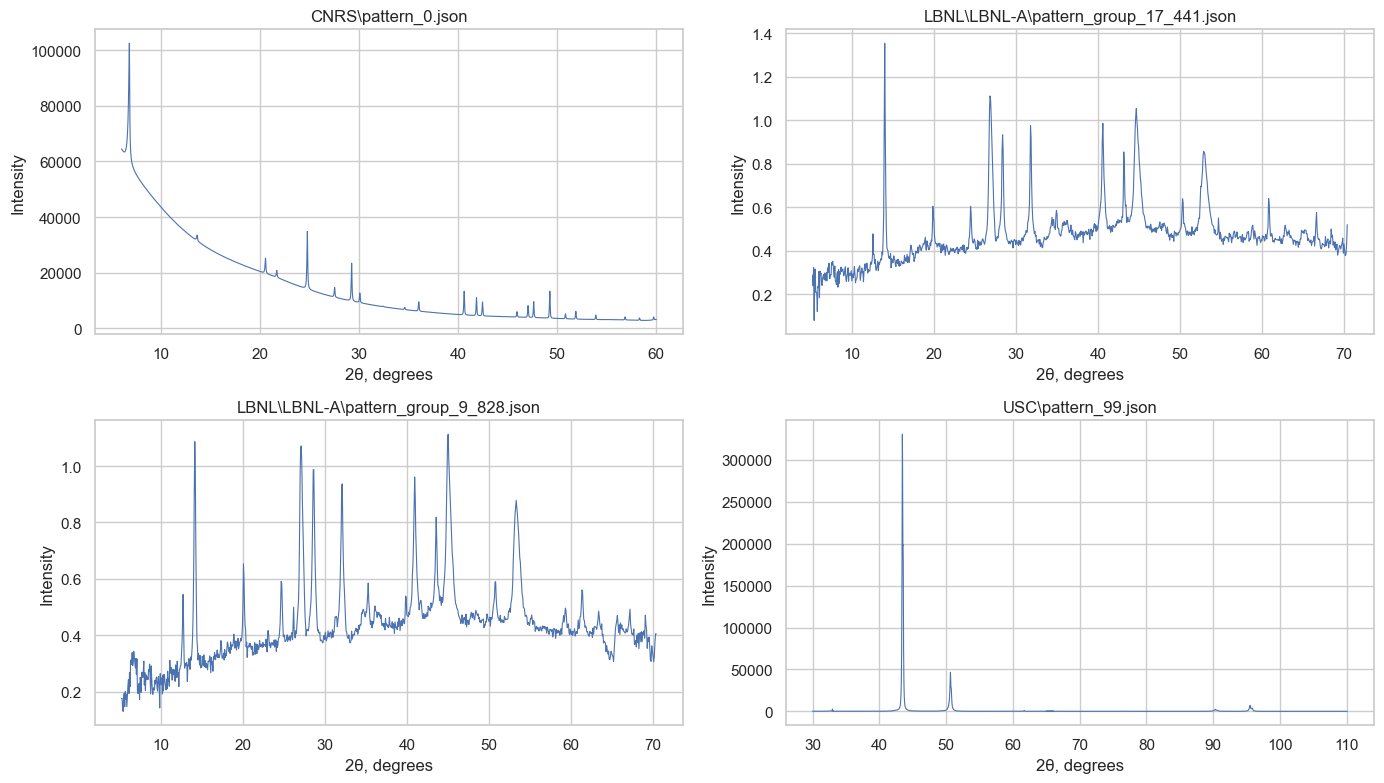

In [ ]:
examples = [opxrd_files[i] for i in np.linspace(0, len(opxrd_files)-1, 4, dtype=int)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, path in zip(axes.ravel(), examples):
    item = json.loads(path.read_text(encoding="utf-8"))

    ax.plot(item["two_theta_values"], item["intensities"], lw=0.8)
    ax.set_title(str(path.relative_to(RAW_SOURCES["opxrd_root"])))
    ax.set_xlabel("2θ, degrees")
    ax.set_ylabel("Intensity")
    
plt.tight_layout()
plt.savefig(FIG_DIR / "opxrd_spectrum_examples.png", dpi=160, bbox_inches="tight")
plt.show()

## Вывод

RRUFF и opXRD являются двумя разными real-доменами: они отличаются происхождением,
сетками, длинами волн и полнотой меток. Поэтому далее для них сохраняются отдельные
роли, маски целевых голов и группировки при оценке.

Фффф